In [1]:
"""
    定义大模型和state
"""
from typing import Literal, TypedDict
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain.tools import tool
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()


# ===============Step 1: 初始化chat模型===============
llm = init_chat_model(
    'deepseek-v4-flash',
    extra_body={'thinking': {'type': 'disabled'}}
)

# ===============Step 2: 定义State，记录用户输入、最终结果===============
class IntentState(MessagesState):
    intent: str  # 意图识别结果

In [2]:
from langchain.agents import create_agent

"""
    定义子图
    一个agent就是一个现成的子图
"""
@tool
def get_weather(city: str) -> str:
    """
    获取城市天气
    :param city: 城市名
    :return: 返回天气信息
    """
    weather_data = {
        "北京": "晴天 25度",
        "上海": "多云 28度",
        "杭州": "小雨 22度",
    }
    return weather_data.get(city, f"未找到{city}的天气信息")

# 组成工具数组
tools = [get_weather]

# ====== 定义Agent ======
weather_agent = create_agent(llm, tools)

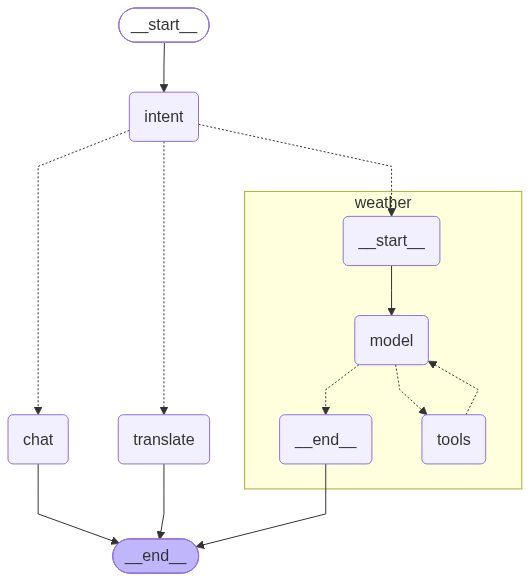

In [3]:
from IPython.core.display import display_png

"""
    定义父图
    拼接工作流
"""

# 闲聊节点
def chat_node(state: IntentState):
    result = llm.invoke(state['messages'])
    return {'messages': [result]}


# 翻译节点
def translate_node(state: IntentState):
    result = llm.invoke(f'''
    按照用户要求翻译，只输出翻译结果，不要任何解释。
    user_query:{state['messages'][-1].content}
    ''')
    return {'messages': [result]}


# 根据用户输入来判断意图的节点
def intent_node(state: IntentState):
    result = llm.invoke(f'''
    请识别用户意图，并只输出意图名称，不要任何解释。,可选的意图名称[chat, weather, translate]
    user_query:{state['messages'][-1].content}
    例如 :
    - 输入:今天天气怎么样?
    - 输出: weather
    ''')
    return {'intent': result.text}


# 意图路由的函数
def intent_router(state: IntentState) -> Literal['chat', 'weather', 'translate']:
    """意图路由的函数"""
    return state['intent']


# ===============Step 5: 创建Graph===============
# 定义状态的类型
builder = StateGraph(IntentState)
# 根据开始节点,用户输入来判断意图的节点,也是大模型调用节点
builder.add_node('intent', intent_node)

# 天气查询子图节点,传入天气智能体
builder.add_node('weather', weather_agent)
# 聊天节点
builder.add_node('chat', chat_node)
# 翻译节点
builder.add_node('translate', translate_node)

builder.add_edge(START, 'intent')
# 路由节点,判断意图识别节点的返回值是什么
builder.add_conditional_edges('intent', intent_router)

# 天气子图到end
builder.add_edge('weather', END)
builder.add_edge('chat', END)
builder.add_edge('translate', END)

routing_graph = builder.compile()

# 画出工作流
display_png(Image(routing_graph.get_graph(xray=True).draw_mermaid_png()))


In [4]:

# 调用父图
result = routing_graph.invoke({'messages': [HumanMessage(content='今天北京天气如何？')]})
for text in result['messages']:
    text.pretty_print()

================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================

I'll help you check the weather in Beijing today.
Tool Calls:
  get_weather (call_00_bxCx66FkCQXNcHYRJ5zw5477)
 Call ID: call_00_bxCx66FkCQXNcHYRJ5zw5477
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

晴天 25度
================================== Ai Message ==================================

今天北京的天气情况如下：

☀️ **晴天**
🌡️ **气温：25度**

天气晴朗，气温舒适宜人。如果您今天有外出计划，是个不错的好天气，适合户外活动。祝您有愉快的一天！如需了解更多信息或有其他问题，随时告诉我。
